In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("assignment2.ipynb")

# Assignment 2: Exploratory Data Analysis in Professional Basketball

In this assignment we'll conduct an exploratory data analysis of professional basketball data.  Basketball is a team sport in which the goal is to try to outscore the amount in a fixed amount of time. Points are scored (either 2 or 3 points) by putting the ball throw a hoop on one end of the court.  An attempt at putting the ball throw the hoop is known as a "shot".  If helpful, you can read more about [the rules of basketball](https://en.wikipedia.org/wiki/Rules_of_basketball).

The National Basketball Association (NBA) is the professional basketball league in the United States and provides a nice website with many statistics gathered on teams and players in the league: [http://stat.nba.com](http://stat.nba.com). 

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

## Question 1: Managing Data Files

We will use data that is available from the NBA. Although the NBA doesn't officially make their data API (Application Programming Interface) public, people have figured out ways to access their data programmatically ([1](https://github.com/swar/nba_api), [2](https://github.com/seemethere/nba_py/wiki/stats.nba.com-Endpoint-Documentation)). However, since the NBA does not offer an official API, it is possible to get our JupyterHub blocked by the site if we access it directly. Therefore, in this assignment, the raw data has been pre-downloaded and is provided to you in a zip file: https://ucsb.box.com/shared/static/z6y3etgikbzbnf0ld4brvc95xtgjcrie.zip

Download and unzip the file to a directory named `data` using command line commands (unzipping on Windows and Mac may not work because different OS have different constraints on filename lengths, etc.). Adding an exclamation point in the Jupyter notebook cell indicates that `bash` shell interpreter will execute your command.
```bash
wget -nc https://ucsb.box.com/shared/static/z6y3etgikbzbnf0ld4brvc95xtgjcrie.zip -O nba-data.zip
unzip -o nba-data.zip -d data
```
What these commands are doing:
* `wget` downloads files ([what do each of the pieces do?](https://explainshell.com/explain?cmd=wget+-nc+https%3A%2F%2Fucsb.box.com%2Fshared%2Fstatic%2F940qiuxyp798gv4nx8iwvazu9qqjs37e.zip+-O+nba-data.zip))
* `unzip` will unzip `nba-data.zip` into a directory named `data` (specified by `-d data`) and will overwrite any same filenames when extracting (specified by `-o`).

</div>

In [2]:
! wget -nc https://ucsb.box.com/shared/static/z6y3etgikbzbnf0ld4brvc95xtgjcrie.zip -O nba-data.zip
! unzip -o nba-data.zip -d data

File ‘nba-data.zip’ already there; not retrieving.
Archive:  nba-data.zip
  inflating: data/commonallplayers?LeagueID=00&Season=2018-19&IsOnlyCurrentSeason=0  
  inflating: data/commonTeamYears?LeagueID=00&Season=2018-19  
  inflating: data/shotchartdetail?PlayerID=101106&PlayerPosition=&Season=2018-19&ContextMeasure=FGA&DateFrom=&DateTo=&GameID=&GameSegment=&LastNGames=0&LeagueID=00&Location=&Month=0&OpponentTeamID=0&Outcome=&Period=0&Position=&RookieYear=&SeasonSegment=&  
  inflating: data/shotchartdetail?PlayerID=101107&PlayerPosition=&Season=2018-19&ContextMeasure=FGA&DateFrom=&DateTo=&GameID=&GameSegment=&LastNGames=0&LeagueID=00&Location=&Month=0&OpponentTeamID=0&Outcome=&Period=0&Position=&RookieYear=&SeasonSegment=&  
  inflating: data/shotchartdetail?PlayerID=101108&PlayerPosition=&Season=2018-19&ContextMeasure=FGA&DateFrom=&DateTo=&GameID=&GameSegment=&LastNGames=0&LeagueID=00&Location=&Month=0&OpponentTeamID=0&Outcome=&Period=0&Position=&RookieYear=&SeasonSegment=&  
  infl

<!-- END QUESTION -->

<div class="alert alert-block alert-success">

After unzipping the files, you will find three types of files in `data/` directory:

* Team data: `commonTeamYears?LeagueID=00&Season=2018-19`
* Player data: `commonallplayers?LeagueID=00&Season=2018-19&IsOnlyCurrentSeason=0`
* Player's shot data: `shotchartdetail?PlayerID=[PlayerID]&PlayerPosition=&Season=2018-19&ContextMeasure=FGA&DateFrom=&DateTo=&GameID=&GameSegment=&LastNGames=0&LeagueID=00&Location=&Month=0&OpponentTeamID=0&Outcome=&Period=0&Position=&RookieYear=&SeasonSegment=&`

Each player's shot data is identified by replacing `[PlayerID]` with their numeric ID.

Here is how we will read in the data:
* Each data file contains text in [JSON (Javascript Object Notation) format](https://www.w3schools.com/python/python_json.asp).
* First, read the data content as text (using [Path.read_text()](https://docs.python.org/3/library/pathlib.html#pathlib.Path.read_text) from `pathlib` module)
* Second, we convert it to a Python dictionary format (using [json.loads()](https://docs.python.org/3/library/json.html#json.loads) in `json` module)
* Third, identify DataFrame content 
* Fourth, identify DataFrame header
* Fifth, assemble DataFrame

Another way to unzip a file is using `zipfile`.

</div>

In [3]:
import zipfile
with zipfile.ZipFile('nba-data.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

<div class="alert alert-block alert-success">

### Question 1a: Team Data

Read the team data file into a pandas DataFrame named `allteams`. Build on the code provided below, which demonstrates the five-step process for reading JSON data into a DataFrame.

</div>

In [4]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

fname  = 'data/commonTeamYears?LeagueID=00&Season=2018-19' # directory_name/file_name
step_1 = Path(fname).read_text()              # str
step_2 = json.loads(step_1)                   # dict
step_3 = step_2['resultSets'][0]['rowSet']    # list 
step_4 = step_2['resultSets'][0]['headers']   # list

In [5]:
# print out each of step_1 through step_4 and understand what each line does

In [6]:
print(step_1, step_2, step_3, step_4)

{"resource":"commonteamyears","parameters":{"LeagueID":"00"},"resultSets":[{"name":"TeamYears","headers":["LEAGUE_ID","TEAM_ID","MIN_YEAR","MAX_YEAR","ABBREVIATION"],"rowSet":[["00",1610612737,"1949","2019","ATL"],["00",1610612738,"1946","2019","BOS"],["00",1610612740,"2002","2019","NOP"],["00",1610612741,"1966","2019","CHI"],["00",1610612742,"1980","2019","DAL"],["00",1610612743,"1976","2019","DEN"],["00",1610612745,"1967","2019","HOU"],["00",1610612746,"1970","2019","LAC"],["00",1610612747,"1948","2019","LAL"],["00",1610612748,"1988","2019","MIA"],["00",1610612749,"1968","2019","MIL"],["00",1610612750,"1989","2019","MIN"],["00",1610612751,"1976","2019","BKN"],["00",1610612752,"1946","2019","NYK"],["00",1610612753,"1989","2019","ORL"],["00",1610612754,"1976","2019","IND"],["00",1610612755,"1949","2019","PHI"],["00",1610612756,"1968","2019","PHX"],["00",1610612757,"1970","2019","POR"],["00",1610612758,"1948","2019","SAC"],["00",1610612759,"1976","2019","SAS"],["00",1610612760,"1967","2

<div class="alert alert-block alert-success">

Using the variables constructed above, assemble the `allteams` DataFrame.

Then, drop any teams that no longer exist as of 2019. These defunct teams have `None` in the `ABBREVIATION` column.

**Hint:** Use a pandas method to remove rows with missing values (NAs).

</div>

In [7]:
allteams = pd.DataFrame(data=step_3, columns=step_4)
#allteams = allteams[allteams['ABBREVIATION'] != None]
allteams = allteams.dropna(subset='ABBREVIATION')

In [8]:
grader.check("q1a")

q1a results: All test cases passed!

<div class="alert alert-block alert-success">

### Question 1b: Player Data

`pathlib` has flexible ways to specify file and directory paths. For example, the following are equivalent:

* `Path('data/commonallplayers?LeagueID=00&Season=2018-19&IsOnlyCurrentSeason=0')`
* `Path('data') / 'commonallplayers?LeagueID=00&Season=2018-19&IsOnlyCurrentSeason=0')`
* `Path('data').joinpath('commonallplayers?LeagueID=00&Season=2018-19&IsOnlyCurrentSeason=0')`

Read the player data file with filename `commonallplayers?LeagueID=00&Season=2018-19&IsOnlyCurrentSeason=0` from the `data/` directory. 

Assemble a pandas DataFrame named `allplayers`, set the row index to `PERSON_ID`, and then sort the index.

</div>

In [9]:
dirname  = 'data' # directory_name
filename = 'commonallplayers?LeagueID=00&Season=2018-19&IsOnlyCurrentSeason=0' # file_name
step_1 = Path(dirname, filename).read_text()
step_2 = json.loads(step_1)
step_3 = step_2['resultSets'][0]['rowSet']
step_4 = step_2['resultSets'][0]['headers']

allplayers = pd.DataFrame(data=step_3, columns=step_4).set_index('PERSON_ID').sort_values(by='PERSON_ID')

In [10]:
grader.check("q1b")

q1b results: All test cases passed!

<div class="alert alert-block alert-success">

### Question 1c: Shots Data

`pathlib` can also find all filenames that match a given pattern using [`Path.glob()` method](https://docs.python.org/3/library/pathlib.html#pathlib.Path.glob).

For example, teams data and players data start with the pattern `common` followed by a wildcard `*`: `common*`. 

We can use this to retrieve two file names with one call:

</div>

In [11]:
two_files = Path('data').glob('common*') # generator: https://www.educative.io/edpresso/generator-vs-iterator-in-python
list(two_files)                          # list

[PosixPath('data/commonTeamYears?LeagueID=00&Season=2018-19'),
 PosixPath('data/commonallplayers?LeagueID=00&Season=2018-19&IsOnlyCurrentSeason=0')]

<div class="alert alert-block alert-success">

All shot data filenames start with `shotchartdetail`. 

Use this pattern to complete the following steps:
1. **First**, use `Path.glob()` to find all matching files and store them in a list called `allshots_files`
2. **Second**, loop over each file in `allshots_files` and assemble a DataFrame using the same JSON parsing steps from Q1a/Q1b
3. **Third**, add each DataFrame as an element to a list named `allshots_list` (so each file becomes one DataFrame in the list)
4. **Fourth**, concatenate all DataFrames into one DataFrame named `allshots`, set the row index to `PLAYER_ID`, and sort the index

</div>

In [12]:
allshots_files = list(Path('data').glob('shot*'))
allshots_files.sort()
allshots_list  = list()

print(allshots_files)
for f in allshots_files:
    step_1 = Path(f).read_text()
    step_2 = json.loads(step_1)
    step_3 = step_2['resultSets'][0]['rowSet']
    step_4 = step_2['resultSets'][0]['headers']
    data_frame = pd.DataFrame(data=step_3, columns=step_4)
    allshots_list.append(data_frame)
    
allshots = pd.concat(allshots_list).set_index('PLAYER_ID').sort_values(by='PLAYER_ID')

[PosixPath('data/shotchartdetail?PlayerID=101106&PlayerPosition=&Season=2018-19&ContextMeasure=FGA&DateFrom=&DateTo=&GameID=&GameSegment=&LastNGames=0&LeagueID=00&Location=&Month=0&OpponentTeamID=0&Outcome=&Period=0&Position=&RookieYear=&SeasonSegment=&'), PosixPath('data/shotchartdetail?PlayerID=101107&PlayerPosition=&Season=2018-19&ContextMeasure=FGA&DateFrom=&DateTo=&GameID=&GameSegment=&LastNGames=0&LeagueID=00&Location=&Month=0&OpponentTeamID=0&Outcome=&Period=0&Position=&RookieYear=&SeasonSegment=&'), PosixPath('data/shotchartdetail?PlayerID=101108&PlayerPosition=&Season=2018-19&ContextMeasure=FGA&DateFrom=&DateTo=&GameID=&GameSegment=&LastNGames=0&LeagueID=00&Location=&Month=0&OpponentTeamID=0&Outcome=&Period=0&Position=&RookieYear=&SeasonSegment=&'), PosixPath('data/shotchartdetail?PlayerID=101109&PlayerPosition=&Season=2018-19&ContextMeasure=FGA&DateFrom=&DateTo=&GameID=&GameSegment=&LastNGames=0&LeagueID=00&Location=&Month=0&OpponentTeamID=0&Outcome=&Period=0&Position=&Rookie

In [13]:
grader.check("q1c")

q1c results: All test cases passed!

<div class="alert alert-block alert-success">

### Question 1d: Extract Stephen Curry's Shot Data

Use [`allplayers.query()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.query.html) to find the player ID (index) associated with "[Stephen Curry](https://en.wikipedia.org/wiki/Stephen_Curry)". Store this ID as a variable named `curry_id` with type `str`. 

Then, subset all of Stephen Curry's shots into a DataFrame named `curry_data`. In the same command, convert the data type of the `SHOT_MADE_FLAG` column to `bool`. Your code should look something like:
```python
curry_data = allshots.query(???).astype(????)
```

**Hint:** Inspect the column names in `allplayers` to find which column contains full player names for constructing your `query_str`.

</div>

In [14]:
# fill-in all ...
query_str = 'DISPLAY_FIRST_LAST == "Stephen Curry"'
curry_id = str(allplayers.query(query_str).index.values[0])
curry_data = allshots.query('PLAYER_ID == ' + curry_id).astype({'SHOT_MADE_FLAG' : bool})


In [15]:
grader.check("q1d")

q1d results: All test cases passed!

<div class="alert alert-block alert-success">

## Question 2: Visualization

</div>

<div class="alert alert-block alert-success">

### Question 2a: All Shots Scatter Plot

Use `seaborn` to create a scatter plot showing the locations of Stephen Curry's shot attempts (`LOC_X` and `LOC_Y`). When you call a seaborn plot function, it returns an axes object—let's call it `ax`. You can customize the plot by calling methods on `ax`.

Set the following properties:
- X-axis limits: (-300, 300)
- Y-axis limits: (-100, 500)

</div>

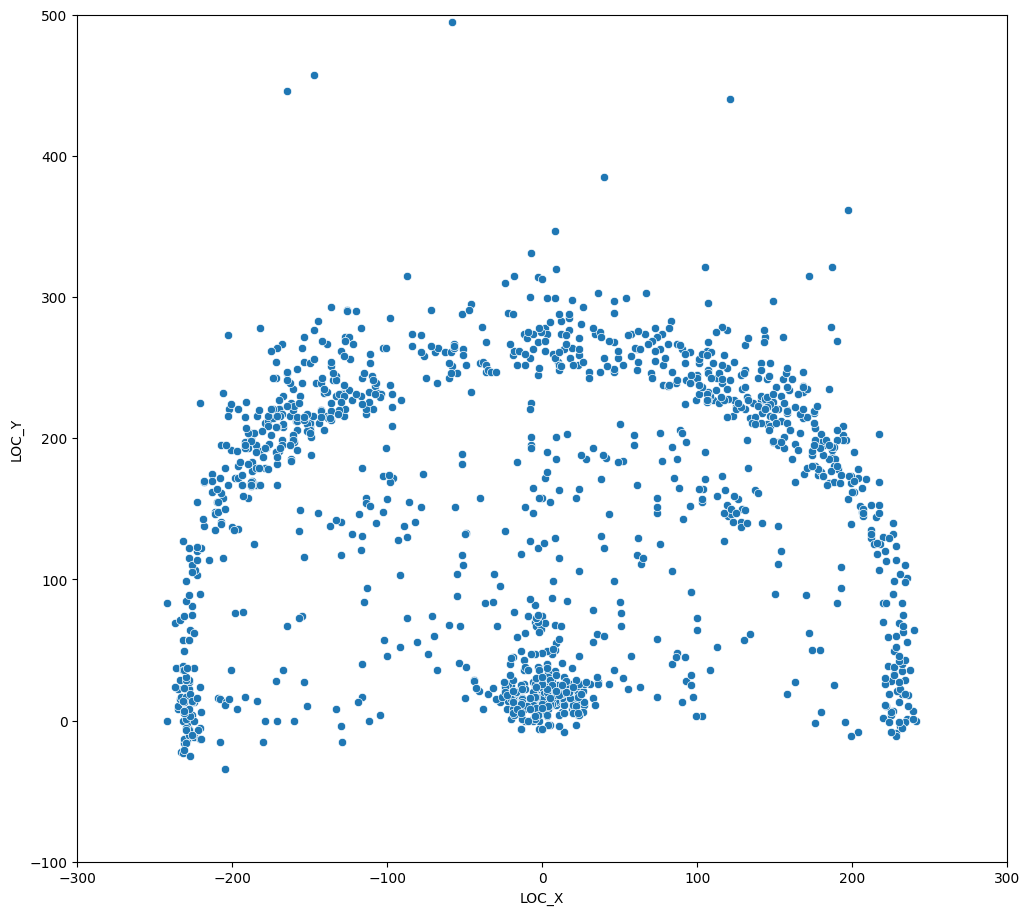

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=[12, 11])
ax2a = sns.scatterplot(data=curry_data, x='LOC_X', y='LOC_Y')

# Set x/y limits and labels
plt.xlim(-300, 300)
plt.ylim(-100, 500)
plt.show()

In [17]:
grader.check("q2a")

q2a results: All test cases passed!

<div class="alert alert-block alert-success">

Understanding any dataset is difficult without context. We've provided a function to help visualize shot locations on an NBA basketball court.

</div>

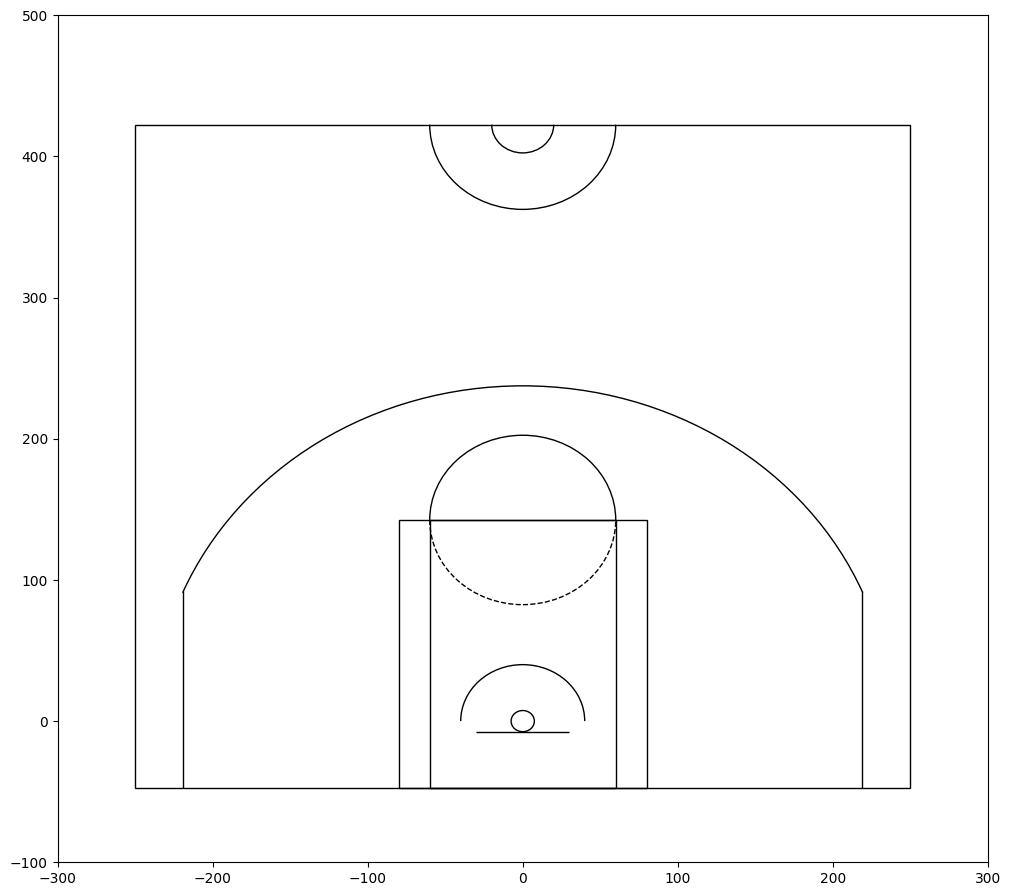

In [18]:
## code is from http://savvastjortjoglou.com/nba-shot-sharts.html
def draw_court(ax=None, color='black', lw=1, outer_lines=False):
    
    from matplotlib.patches import Circle, Rectangle, Arc
    from matplotlib.pyplot import gca
    
    # If an axes object isn't provided to plot onto, just get current one
    if ax is None:
        ax = gca()

    # Create the various parts of an NBA basketball court

    # Create the basketball hoop
    # Diameter of a hoop is 18" so it has a radius of 9", which is a value
    # 7.5 in our coordinate system
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)

    # Create backboard
    backboard = Rectangle((-30, -7.5), 60, 0, linewidth=lw, color=color)

    # The paint
    # Create the outer box 0f the paint, width=16ft, height=19ft
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color,
                          fill=False)
    # Create the inner box of the paint, widt=12ft, height=19ft
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color,
                          fill=False)

    # Create free throw top arc
    top_free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180,
                         linewidth=lw, color=color, fill=False)
    # Create free throw bottom arc
    bottom_free_throw = Arc((0, 142.5), 120, 120, theta1=180, theta2=0,
                            linewidth=lw, color=color, linestyle='dashed')
    # Restricted Zone, it is an arc with 4ft radius from center of the hoop
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw,
                     color=color)

    # Three point line
    # Create the side 3pt lines, they are 14ft long before they begin to arc
    corner_three_a = Rectangle((-219, -47.5), 0, 140, linewidth=lw,
                               color=color)
    corner_three_b = Rectangle((219, -47.5), 0, 140, linewidth=lw, color=color)
    # 3pt arc - center of arc will be the hoop, arc is 23'9" away from hoop
    # I just played around with the theta values until they lined up with the 
    # threes
    three_arc = Arc((0, 0), 475, 475, theta1=22.5, theta2=157.5, linewidth=lw,
                    color=color)

    # Center Court
    center_outer_arc = Arc((0, 422.5), 120, 120, theta1=180, theta2=0,
                           linewidth=lw, color=color)
    center_inner_arc = Arc((0, 422.5), 40, 40, theta1=180, theta2=0,
                           linewidth=lw, color=color)

    # List of the court elements to be plotted onto the axes
    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                      bottom_free_throw, restricted, corner_three_a,
                      corner_three_b, three_arc, center_outer_arc,
                      center_inner_arc]

    if outer_lines:
        # Draw the half-court line, baseline and side-out bound lines
        outer_lines = Rectangle((-250, -47.5), 500, 470, linewidth=lw,
                                color=color, fill=False)
        court_elements.append(outer_lines)

    # Add the court elements onto the axes
    for element in court_elements:
        ax.add_patch(element)

    return ax

plt.figure(figsize=(12,11))
draw_court(outer_lines=True)
plt.xlim(-300,300)
plt.ylim(-100,500)
plt.show()

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

### Question 2b: All Shots Scatter Plot with Court Overlay

Create another scatter plot of Stephen Curry's shots, but this time with additional features:

1. **Color the points** by whether the shot was made or missed (use the `SHOT_MADE_FLAG` column)
2. **Use different markers** to distinguish made vs missed shots:
   - Missed shots (0): Use 'X' symbol
   - Made shots (1): Use circular 'o' symbol
3. **Overlay the court**: Call `draw_court(outer_lines=True)` to show the basketball court outline
4. **Set axis limits**:
   - X-axis: (-300, 300)
   - Y-axis: (-100, 500)

Save the axes object returned by seaborn in a variable called `ax`.

</div>

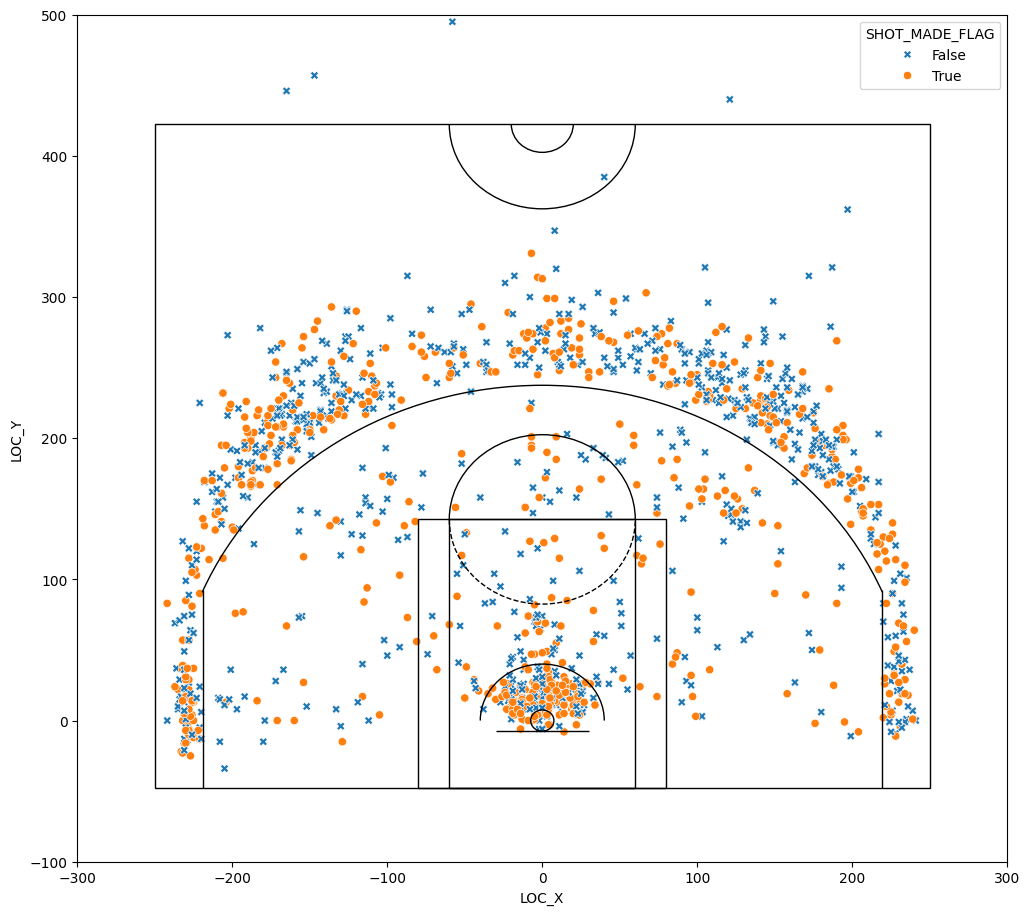

In [19]:
plt.figure(figsize=(12, 11))
markers = {0 : "X", 1 : "o"}
ax = sns.scatterplot(data=curry_data, x='LOC_X', y='LOC_Y', hue='SHOT_MADE_FLAG', style='SHOT_MADE_FLAG', markers=markers)
draw_court(outer_lines=True)
plt.xlim(-300, 300)
plt.ylim(-100, 500)
plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

### Question 2c: Analyzing the Visualization

In 3-5 sentences, analyze the effectiveness of this visualization:

- What does it reveal about the types of shots Stephen Curry prefers to take?
- How well does it show which shots he makes versus misses?
- What are the strengths and weaknesses of this visualization approach?
- How could it be improved to better communicate Curry's shooting patterns?

</div>

**SOLUTION**

We can see that that Stephen Curry usually shoots from wither right below the basket, or from right outside the 3 point line, he does not shoot inside the 3 point line often unless he is right under the basket. It also appears that more often then not, he makes his shots when shooting right under the basket. I would communicate to Curry that he should not try shooting when he is far from the 3pt line because he has not made any of those shots. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

### Question 2d: A Hexbin Plot

Create a [hexbin plot with marginal histograms](https://seaborn.pydata.org/examples/hexbin_marginals.html) to visualize Stephen Curry's shot locations. Hexbin plots are useful for dense data because they aggregate nearby points into hexagonal bins.

Refer to the seaborn documentation on [figure aesthetics](https://seaborn.pydata.org/tutorial/aesthetics.html) to understand what each command does in the provided code.

</div>

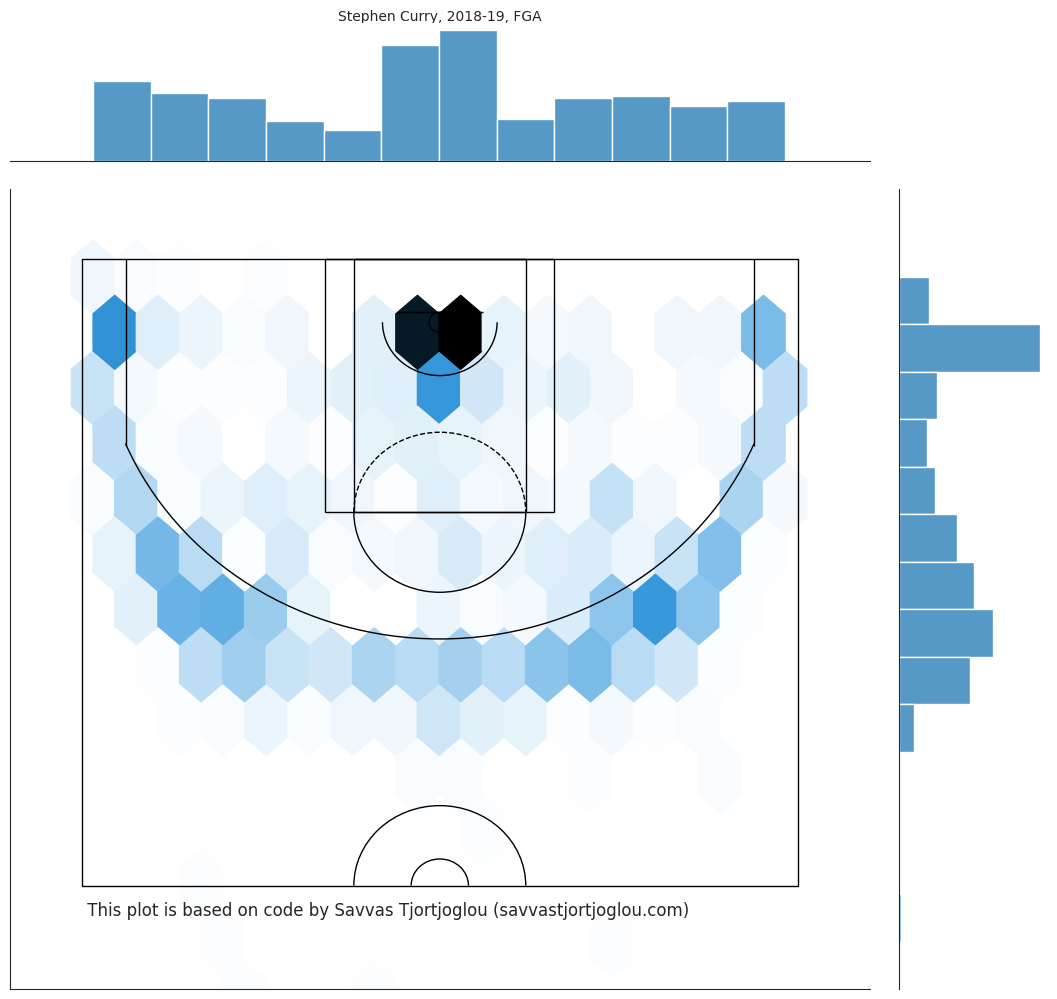

In [20]:
sns.set_style("white")
joint_shot_chart = sns.jointplot(data=curry_data, x='LOC_X', y='LOC_Y', kind='hex')
joint_shot_chart.fig.set_size_inches(12,11)

# A joint plot has 3 Axes, the first one called ax_joint 
# is the one we want to draw our court onto and adjust some other settings
ax = joint_shot_chart.ax_joint
draw_court(ax, outer_lines=True)

# Adjust the axis limits and orientation of the plot in order
# to plot half court, with the hoop by the top of the plot
ax.set_xlim(-300, 300)
ax.set_ylim(500, -100)

# Get rid of axis labels and tick marks
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(labelbottom=False, labelleft=False)

# Add a title
ax.set_title('Stephen Curry, 2018-19, FGA', 
             y=1.2, fontsize=10)

# Add Data Source and Author
ax.text(-250,445,'\n This plot is based on code by Savvas Tjortjoglou (savvastjortjoglou.com)',
        fontsize=12);

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

## Question 2e: Contour Plots

Contour plots are another way to visualize shot distributions. Use `displot()` with `kind='kde'` in seaborn to create kernel density estimate contour plots.

Create two visualizations:
1. Compare missed vs. made shots using the `SHOT_MADE_FLAG` column
2. Compare shots across different zones using the `SHOT_ZONE_AREA` column

**Hint:** See the [seaborn distribution documentation](https://seaborn.pydata.org/tutorial/distributions.html) for examples.

</div>

In [21]:
curry_data.head()

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,...,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM
PLAYER_ID,,,,,,,,,,,,,,,,,,,,,
201939,Shot Chart Detail,0021800862,117,Stephen Curry,1610612744,Golden State Warriors,1,3,55,Made Shot,...,Center(C),16-24 ft.,17,2,172,1,True,20190213,POR,GSW
201939,Shot Chart Detail,0021800862,600,Stephen Curry,1610612744,Golden State Warriors,4,5,9,Missed Shot,...,Right Side Center(RC),24+ ft.,26,116,239,1,False,20190213,POR,GSW
201939,Shot Chart Detail,0021800862,576,Stephen Curry,1610612744,Golden State Warriors,4,6,55,Missed Shot,...,Right Side(R),24+ ft.,22,225,28,1,False,20190213,POR,GSW
201939,Shot Chart Detail,0021800862,484,Stephen Curry,1610612744,Golden State Warriors,3,2,24,Missed Shot,...,Left Side(L),24+ ft.,23,-235,8,1,False,20190213,POR,GSW
201939,Shot Chart Detail,0021800862,467,Stephen Curry,1610612744,Golden State Warriors,3,3,3,Missed Shot,...,Right Side(R),16-24 ft.,22,193,109,1,False,20190213,POR,GSW


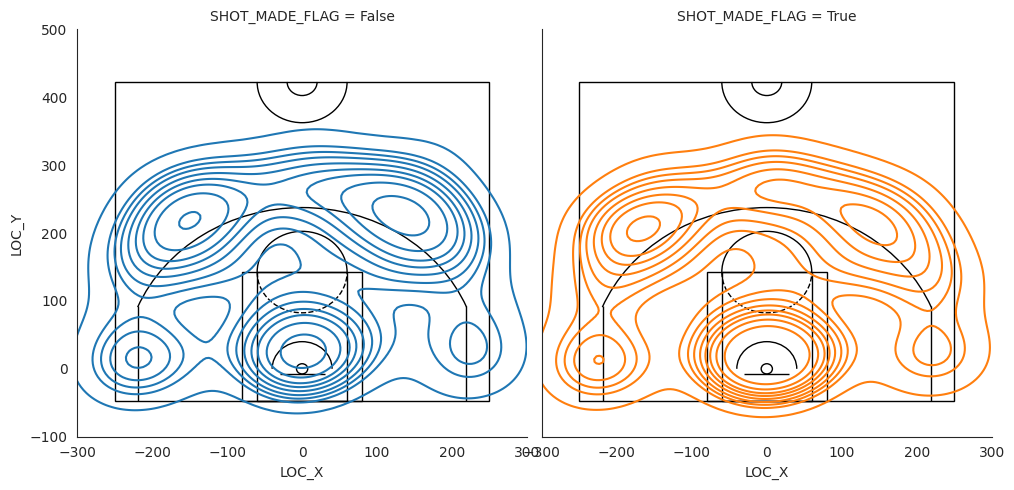

In [22]:
# Visualize Stephen Curry's made and missed shots
# Fill-in ...
contour_miss_made= sns.displot(x='LOC_X', y='LOC_Y', data=curry_data, kind='kde', legend = False, col = 'SHOT_MADE_FLAG', hue  = 'SHOT_MADE_FLAG', col_wrap = 2) 
for ax in contour_miss_made.axes.flat:
    ax = draw_court(ax, outer_lines=True)
    ax.set_xlim(-300,300)
    ax.set_ylim(-100,500)

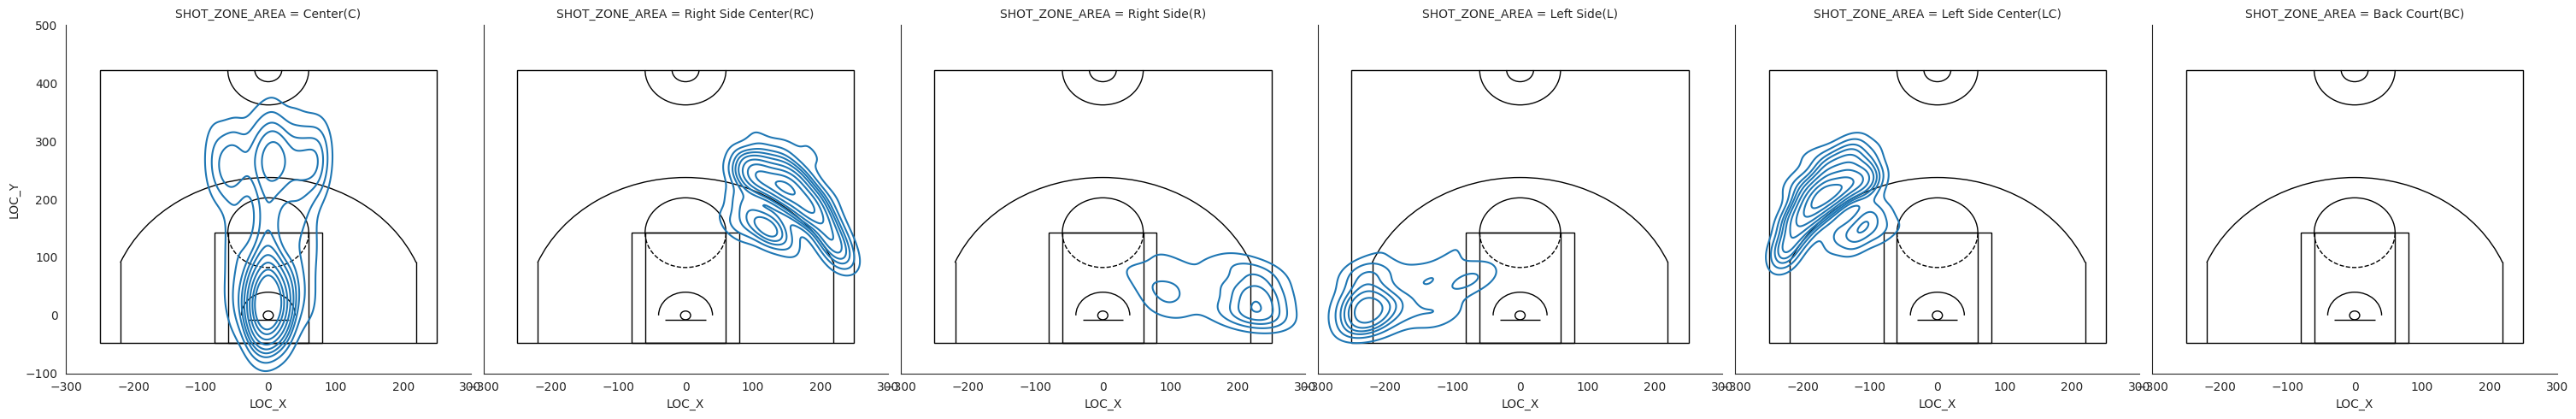

In [23]:
# Visualize Stephen Curry's shots' area
# Fill-in ...
contour_area= sns.displot(x='LOC_X', y='LOC_Y', data=curry_data, kind='kde', legend = False, col ='SHOT_ZONE_AREA', col_wrap = 6) 
for ax in contour_area.axes.flat:
    ax = draw_court(ax, outer_lines=True)
    ax.set_xlim(-300,300)
    ax.set_ylim(-100,500)

In [24]:
curry_data.SHOT_ZONE_AREA.value_counts()

SHOT_ZONE_AREA
Center(C)                506
Right Side Center(RC)    309
Left Side Center(LC)     290
Left Side(L)             127
Right Side(R)             97
Back Court(BC)            11
Name: count, dtype: int64

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

Compare and contrast the three visualization types you've created:

- Scatter plot (Q2b)
- Hexbin plot (Q2d)  
- Contour plot (Q2e)

Discuss the advantages and disadvantages of each approach. When would you use one type over the others?

</div>

**Solution**

I like that for the hexbin plot, it is easiest to view where he shoots the most. But to see where he makes the most shots, it is easier to get this information from either the scatterplot or the contour plot. In the contour plot showing the shot area, this helps view where he is shooting from based on certain court locations. 

<!-- END QUESTION -->

<div class="alert alert-block alert-success">

## Question 3: Binning and Smoothing Shots

So far, we have worked with DataFrames that represent each shot as a single observation (one row per shot). However, this isn't the most convenient data structure for the spatial analyses we'll pursue next.

In this section, we will divide the court into square regions and create a matrix containing the number of shots taken in each region. We'll bin the court into a 2D histogram where we count the number of shots falling into each bin. Fortunately, this is relatively straightforward to implement using the `numpy` module.

</div>

<div class="alert alert-block alert-success">

### Question 3a: 2D Binning and Smoothing

Complete the `bin_shots` function below:

1. Use `np.histogram2d` to count shots in each bin. The parameter `bin_edges` is a tuple of the form `(xedges, yedges)` defining the bin boundaries.
2. If `density=True`, apply Gaussian smoothing by calling `ndimage.gaussian_filter` on the histogram result with smoothing parameter `sigma`. Then normalize so the total mass sums to 1.

This creates a smoothed density surface representing shot frequency across court locations.

</div>

In [25]:
def bin_shots(df, bin_edges, density=False, sigma=1):
    
    """Given data frame of shots, compute a 2d matrix of binned counts is computed
    
    Args:
        df: data frame of shotchartdetail from nba.com. 
            At the minimum, variables named LOCX and LOCY are required.
        bin_edges: bin edge definition: edges in x and edges in y
    
    Returns:
        binned: counts
        xedges: bin edges in X direction
        yedges: bin edges in Y direction
    """
    import numpy as np
    from scipy import ndimage
    
    ## inspect return values of np.histogram2d and 
    # assign to variables: xedges, yedges, binned
    binned, xedges, yedges = np.histogram2d(df['LOC_X'], df['LOC_Y'], bins=bin_edges)
    
    if density:

        # Recompute 'binned' using "gaussian_filter"
        binned = ndimage.gaussian_filter(binned, sigma=sigma)
        
        # Normalize the histogram to be a "density", e.g. mass across all bins sums to 1.
        binned /= np.sum(binned)
    
    return(binned, xedges, yedges)


In [26]:
grader.check("q3a")

q3a results: All test cases passed!

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

### Question 3b: Visualize Binning on Curry's Data

Call `bin_shots` three times on `curry_data` to create:

1. **`curry_binned_unsmoothed`**: Binned but unsmoothed shot counts (use `density=False`)
2. **`curry_binned_smoothed1`**: Smoothed density with `sigma=1`
3. **`curry_binned_smoothed5`**: Smoothed density with `sigma=5`

Use the bin edges defined below for all three:

</div>

In [27]:
## bin edge definitions in inches
xedges = np.linspace(start=-300, stop=300, num=151)
yedges = np.linspace(start=-48, stop=372, num=106)

_Type your answer here, replacing this text._

In [28]:
bin_edges = (xedges, yedges)
# fill-in all ...
curry_binned_unsmoothed, xe, ye = bin_shots(df=curry_data, bin_edges=bin_edges, density=False)
curry_binned_smoothed1,  xe, ye = bin_shots(df=curry_data, bin_edges=bin_edges, density=True, sigma=1)
curry_binned_smoothed5,  xe, ye = bin_shots(df=curry_data, bin_edges=bin_edges, density=True, sigma=5) 


In [29]:
def plot_shotchart(binned_counts, xedges, yedges, ax=None, use_log=False, cmap = 'Reds'):
    
    """Plots 2d heatmap from vectorized heatmap counts
    
    Args:
        hist_counts: vectorized output of numpy.histogram2d
        xedges, yedges: bin edges in arrays
        ax: figure axes [None]
        use_log: will convert count x to log(x+1) to increase visibility [False]
        cmap: Set the color map https://matplotlib.org/examples/color/colormaps_reference.html
    Returns:
        ax: axes with plot
    """
    
    import numpy as np
    import matplotlib.pyplot as plt
    
    ## number of x and y bins.  
    nx = xedges.size - 1
    ny = yedges.size - 1

    X, Y = np.meshgrid(xedges, yedges)
    
    if use_log:
        counts = np.log(binned_counts + 1)
        
    if ax is None:
        fig, ax = plt.subplots(1,1)
    
    ax.pcolormesh(X, Y, binned_counts.T, cmap=cmap) 
    ax.set_aspect('equal')
    
    draw_court(ax)
    
    return(ax)

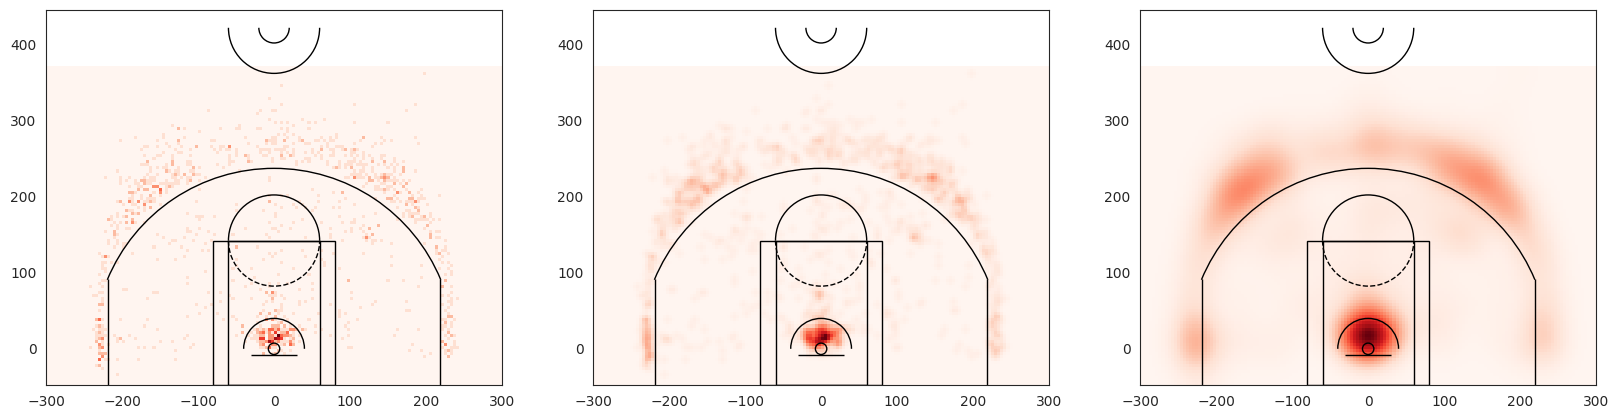

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(20,60))
plot_shotchart(curry_binned_unsmoothed, xe, ye, ax=ax[0], use_log=True)
plot_shotchart(curry_binned_smoothed1, xe, ye, ax=ax[1], use_log=False)
plot_shotchart(curry_binned_smoothed5, xe, ye, ax=ax[2], use_log=False)

fig.show()

<!-- END QUESTION -->

<div class="alert alert-block alert-success">

## Vectorize Shot Images

- Here we proceed create a dictionary of smoothed patterns, each vectorized into a 1-d array (like Lab 6)
- In this case, the object `all_smooth` is a dictionary that consists of arrays of length `15750`. 
- Each entry in `all_smooth` represents the smoothed frequency of shots along the bins generated in the code above for a given player.

</div>

In [31]:
## number of bins is one less than number of edges (remember homework 1)
nx = xedges.size - 1
ny = yedges.size - 1

## 2d histogram containers for binned counts and smoothed binned counts
all_counts = []
all_smooth = []
pids = []

## 2d histogram containers for binned counts and smoothed binned counts

## data matrix: players (row) by vectorized 2-d court locations (column)
for i, one in enumerate(allshots.groupby('PLAYER_ID')):
    
    ## what does this line do?
    pid, pdf = one
        
    num_shots = len(pdf.index)
    if(num_shots > 100): 
        
        tmp1, xedges, yedges = bin_shots(pdf, bin_edges=(xedges, yedges), density=True, sigma=2)
        tmp2, xedges, yedges = bin_shots(pdf, bin_edges=(xedges, yedges), density=False)
    
        ## vectorize and store into list
        all_smooth += [tmp1.reshape(-1)]
        all_counts += [tmp2.reshape(-1)]
        pids += [pid]
        
X = np.vstack(all_smooth).T
p, n = X.shape

print('Number of shot regions (p):', p)
print('Number of players (n):', n)

Number of shot regions (p): 15750
Number of players (n): 388


<div class="alert alert-block alert-success">

## Question 4: Non-negative Matrix Factorization (NMF) 

The non-negative matrix factorization is a dimension reduction technique that is often applied to image data.  It is similar to PCA except that is only applicable for strictly positive data.  We can apply the NMF to vectorized versions of the shot surface. This is useful because we can convert the observed matrix of shot surfaces into:
* Bases: Identifying modes of shooting style (number of modes is determined by `n_components` argument to `NMF` function below)
* Coefficients: How each players shooting style could be expressed as a (positive) linear combination of these bases

The NMF solves the following problem: given some matrix $X$ is $p\times n$ matrix, NMF computes the following factorization:
$$ \min_{W,H} \| X - WH \|_F\\
\text{ subject to } W\geq 0,\ H\geq 0, $$
where $W$ is ${p\times r}$ matrix and $H$ is ${r\times n}$ matrix.

In this homework, we have the following:
 
#### The data matrix $X$ 
$X$ is of dimension $n$={number of players} and $p$={number of total square bins on the court}. Each column corresponds to a player, with entries corresponding to a "flattened" or "vectorized" version of the 2d histograms plotted in part 4b.

#### Bases matrix: $W$

Columns $W_i$ contain the shot "bases". First, we will try it with $r=3$ bins in 5a, and then with $r=10$ bins in 5d.

#### Coefficient matrix: H

Each column of $H$ gives a coefficient for each of the bases vectors in $W$, and there are $n$ columns for each player.


The `sklearn` library is one of the main Python machine learning libraries.  It has a built in NMF function for us.  The function below runs this function and normalizes the basis surfaces to sum to 1.

</div>

In [32]:
## Non-negative Matrix Factorization
def non_negative_marix_decomp(n_components, array_data):
    import sklearn.decomposition as skld
    model = skld.NMF(n_components=n_components, init='nndsvda', max_iter=500, random_state=0)
    W = model.fit_transform(array_data)
    
    # Normalize basis vectors to sum to 1
    Wsum = W.sum(axis=0)
    W = W/Wsum
    
    ## fix H correspondingly
    H = model.components_
    H = (H.T * Wsum).T

    nmf = (W, H)
    return(nmf)

<div class="alert alert-block alert-success">

### Question 4a: Computing NMF Factorization

Compute the NMF on all players' shot charts (matrix `X`) with `n_components = 3`. This means each player's shot chart can be represented as a positive linear combination of 3 "basis" shot patterns.

Use the `non_negative_marix_decomp` function provided above. It returns a tuple `(W, H)` where:
- `W` contains the basis shot patterns (columns)
- `H` contains the coefficients showing how much each player uses each basis pattern (rows)

Store the results as `W3` and `H3`.

</div>

In [33]:
# fill in ...
W3, H3 = non_negative_marix_decomp(n_components=3, array_data=X)

In [34]:
grader.check("q4a")

q4a results: All test cases passed!

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

### Question 4b: Visualizing Shot Archetypes

Plot the three basis shot patterns by visualizing each column of `W3`.

Complete the `plot_vectorized_shotchart` function below. This function:
1. Takes a vectorized (flattened) array of binned shot counts
2. Reshapes it back into a 2D matrix using the provided `xedges` and `yedges`
3. Calls `plot_shotchart` to visualize the 2D heatmap

**Hint:** Use `numpy.reshape()` to convert from 1D back to 2D: [https://docs.scipy.org/doc/numpy/reference/generated/numpy.reshape.html](https://docs.scipy.org/doc/numpy/reference/generated/numpy.reshape.html)

After completing the function, create a figure with 3 side-by-side subplots showing all 3 basis patterns.

</div>

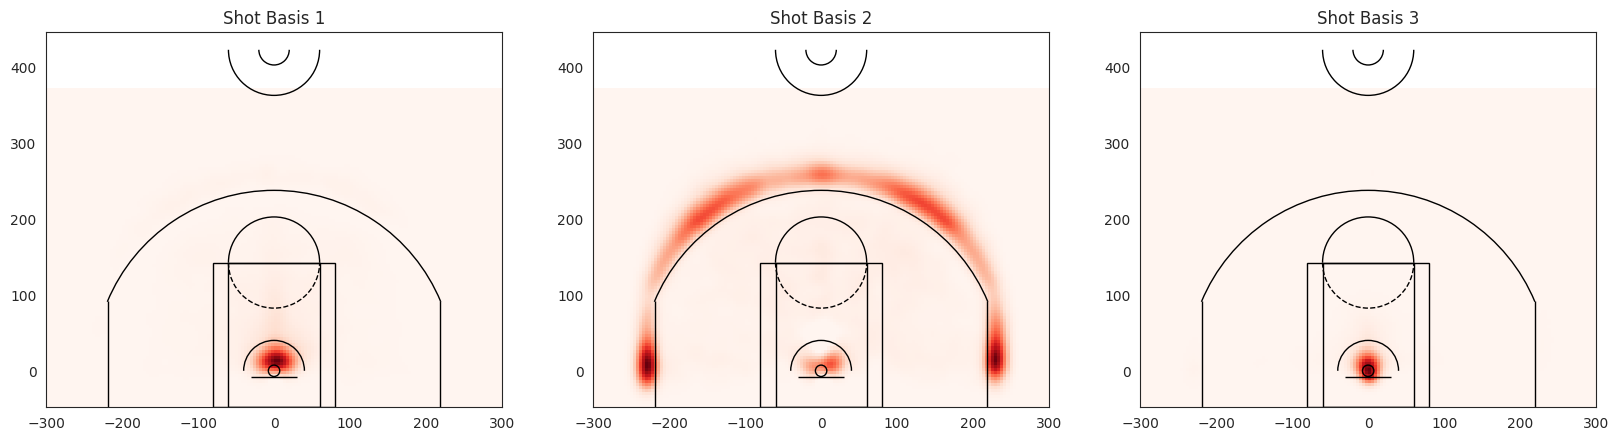

In [35]:
def plot_vectorized_shotchart(vec_counts, xedges, yedges, ax=None, use_log=False, cmap = 'Reds'):
    
    """Plots 2d heatmap from vectorized heatmap counts
    
    Args:
        hist_counts: vectorized output of numpy.histogram2d
        xedges, yedges: bin edges in arrays
        ax: figure axes [None]
        use_log: will convert count x to log(x+1) to increase visibility [False]
        cmap: Set the color map https://matplotlib.org/examples/color/colormaps_reference.html
    Returns:
        ax: axes with plot
    """

    nx = xedges.size - 1
    ny = yedges.size - 1
    
    # use reshape to convert a vectorized counts back into a 2d histogram
    two_d_counts = np.reshape(vec_counts, (nx, ny))
    
    return(plot_shotchart(two_d_counts, xedges, yedges, ax=ax, use_log=use_log, cmap=cmap))

fig, ax = plt.subplots(1, 3, figsize=(20,60))

## Write a for loop
for i in range(3):
    plot_vectorized_shotchart(W3[:, i], xedges, yedges, ax=ax[i])
    ax[i].set_title('Shot Basis %i' % (i+1))

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

### Question 4c: Detailed Modeling with 10 Components

Re-run the NMF analysis, this time with `n_components = 10` instead of 3. This will discover 10 fundamental shooting patterns rather than just 3, providing more granular detail about different player types.

1. Compute NMF with 10 components and store the results as `W10` and `H10`
2. Visualize all 10 basis patterns using `plot_vectorized_shotchart` on each column of `W10`
3. Arrange the 10 plots in a 2x5 grid (2 rows, 5 columns)

**Hint:** Study the following code to understand subplot arrays:
```python
fig, ax = plt.subplots(2, 5, figsize=(20, 7))
ax = ax.flatten() # turn ax into a flat array
ax[0].set_title('hello')
ax[9].set_title('there')
fig.show()
```

</div>

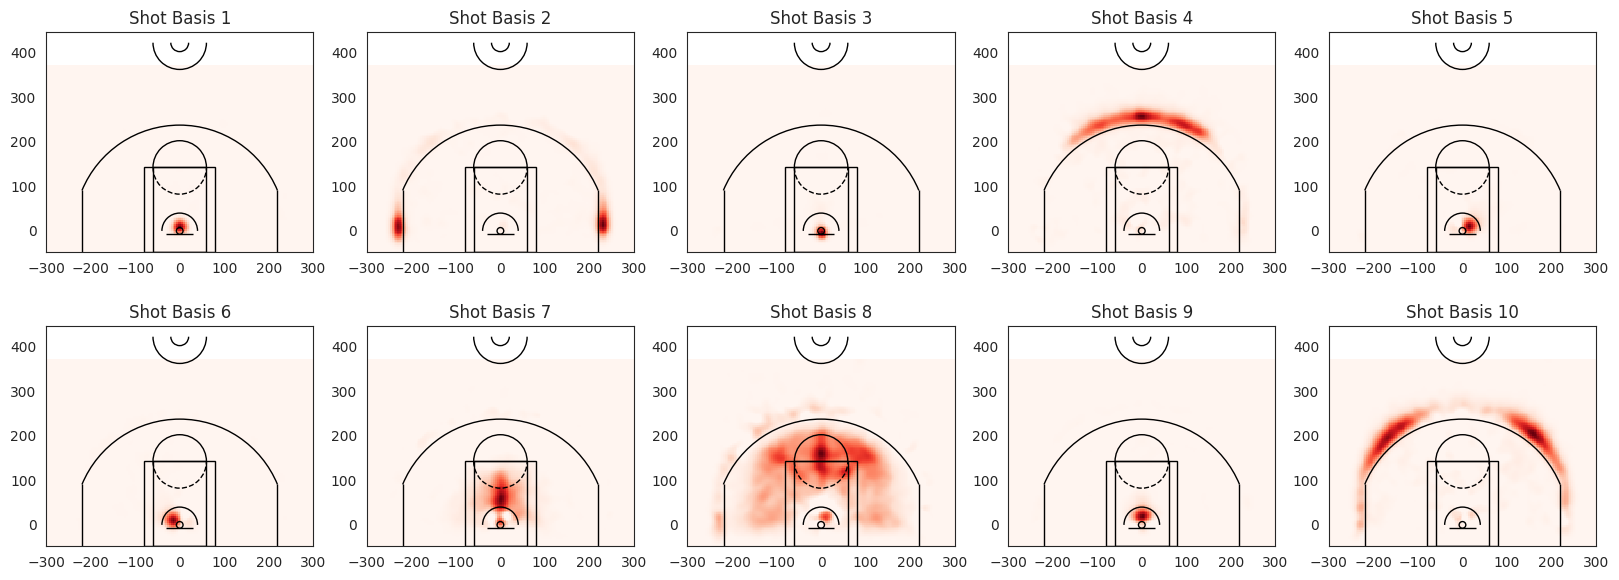

In [36]:
W10, H10 = non_negative_marix_decomp(n_components=10, array_data=X)

fig, ax = plt.subplots(2, 5, figsize=(20, 7))

## Write a for loop
for i in range(10):
    r, c = i//5, i%5
    plot_vectorized_shotchart(W10[:, i], xedges, yedges, ax=ax[r, c])
    ax[i//5, i % 5].set_title('Shot Basis %i' % (i+1))


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

If you did things correctly, you should be really impressed! We've identified potentially interesting patterns of shooting styles without actually specifying anything about the way basketball is played or where the relevant lines are on the court. The resulting patterns are based only on the actual shooting behavior of the players.

Even more impressive is that we're capturing similarity in shooting patterns across regions that are far apart on the court. One reason we can do this is that a basketball court is symmetric along the width of the court (i.e., symmetric about x=0). However, people tend to be left- or right-hand dominant, which might affect their shooting preferences.

Look carefully at the shot basis plots above: **Is there any evidence of asymmetry in player shooting behavior?** Refer to specific basis images in your answer.

</div>

**SOLUTION**

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

Repeat the analysis from Question 4c: plot the original shot chart, reconstructed shot chart (using 10 components), and residual for **LaMarcus Aldridge**.

Use `X10_hat = W10 @ H10` to compute the reconstructed matrix with 10 components.

</div>

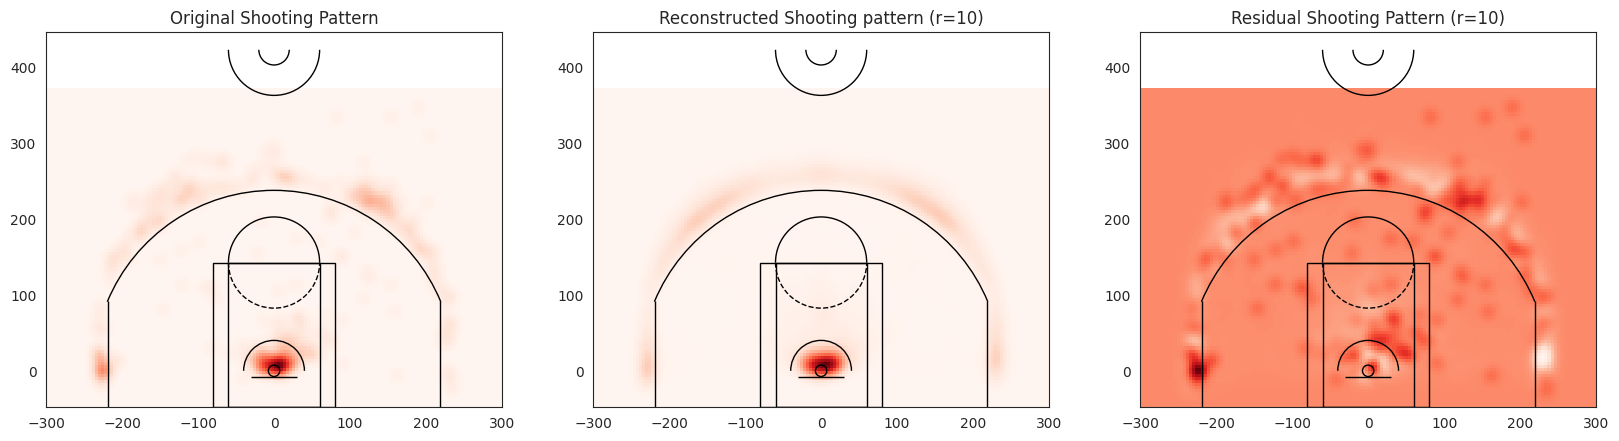

In [38]:
X10_hat = W10 @ H10

fig, ax = plt.subplots(1, 3, figsize=(20,60))

to_plot_idx = 10 # choose a player index to plot

original_shotchart = X[:, to_plot_idx]
reconstructed_shotchart = X10_hat[:, to_plot_idx]
residual_chart = original_shotchart - reconstructed_shotchart

plot_vectorized_shotchart(original_shotchart, xedges, yedges, ax=ax[0])
plot_vectorized_shotchart(reconstructed_shotchart, xedges, yedges, ax=ax[1])
plot_vectorized_shotchart(residual_chart, xedges, yedges, ax=ax[2])

ax[0].set_title('Original Shooting Pattern')
ax[1].set_title('Reconstructed Shooting pattern (r=10)')
ax[2].set_title('Residual Shooting Pattern (r=10)');

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

## Question 5: Downstream Analysis

### Question 5a: Reconstruction Error

Now we will reconstruct each player's shooting pattern using the NMF approximation. By "reconstructing," we mean computing the approximation $$\hat{X} = WH$$

Find $\hat{X}$ by multiplying `W` and `H`. In Python, the `@` symbol performs matrix multiplication.

After computing $\hat{X}$, visualize three plots for player **LaMarcus Aldridge**:
1. **Original**: The actual shooting pattern from matrix $X$
2. **Reconstructed**: The approximation from $\hat{X} = W_3 H_3$ (using 3 components)
3. **Residual**: The difference $X - \hat{X}$ showing what the model misses

Use `plot_vectorized_shotchart` to visualize each pattern.

</div>

_Type your answer here, replacing this text._

In [41]:
X3_hat = W3 @ H3

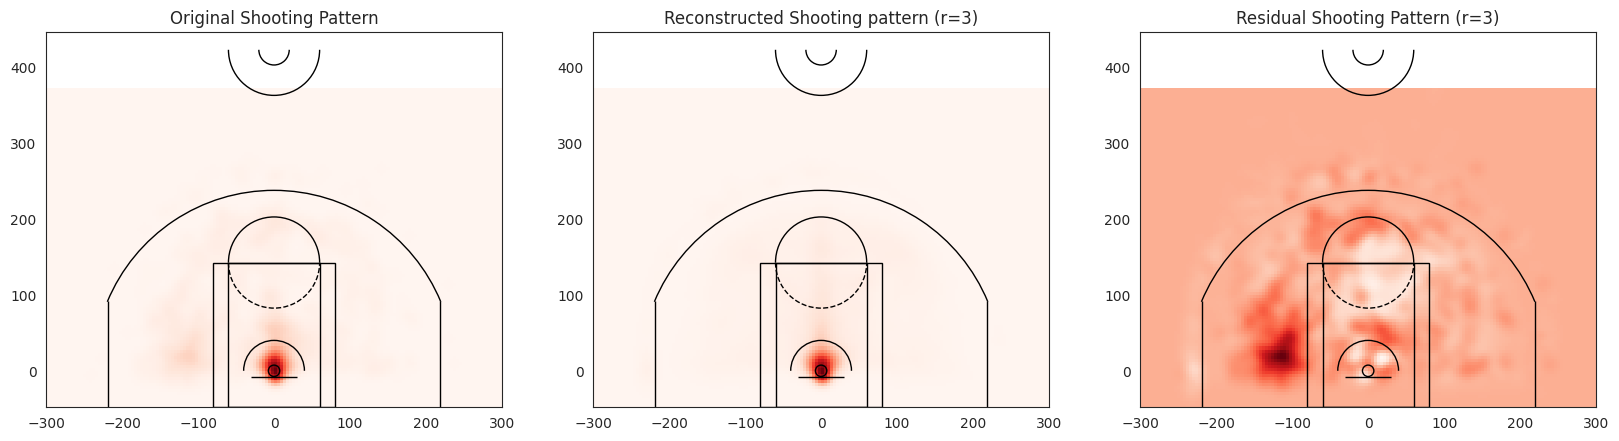

In [77]:
# Find the player_id of LaMarcus Aldridge
player_id = allplayers[allplayers['DISPLAY_FIRST_LAST'] == 'LaMarcus Aldridge'].index[0]

## find index in X corresponding to that player
to_plot_idx = np.where(pids == player_id)[0][0]

fig, ax = plt.subplots(1, 3, figsize=(20,60))

## Call plot_vectorized_shot_chart
original_shotchart = plot_vectorized_shotchart(X[:, to_plot_idx], xedges, yedges, ax=ax[0])
reconstructed_shotchart = plot_vectorized_shotchart(X3_hat[:, to_plot_idx], xedges, yedges, ax=ax[1])
residual_chart = plot_vectorized_shotchart(X[:, to_plot_idx] - X3_hat[:, to_plot_idx], xedges, yedges, ax=ax[2])

# print(max(abs(X3_hat[:, to_plot_idx] - X[:, to_plot_idx])))
ax[0].set_title('Original Shooting Pattern')
ax[1].set_title('Reconstructed Shooting pattern (r=3)')
ax[2].set_title('Residual Shooting Pattern (r=3)')
None # prevents the title string from showing up as output

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

### Question 5b: Choice of Colormap

**Part 1:** Why does it make sense to use a _sequential_ colormap (like 'Reds') for the original and reconstructed shot charts, but a _diverging_ colormap (like 'RdBu') for the residual?

**Hint:** Read the introduction to colormaps [here](https://matplotlib.org/users/colormaps.html) to understand the difference between sequential and diverging colormaps.

</div>

**SOLUTION**

A sequential colormap makes sense because we are looking at the magnitude on a one sided scale where the darker the color means the more shots taken. For a diverging colormap, this shows the deviations around 0 and can be useful to visualize when more or less shots taken than our prediction. 

<div class="alert alert-block alert-success">

**Part 2:** Based on the residual plot for LaMarcus Aldridge, where on the court does he shoot **more** than the NMF model predicts? Where does he shoot **less** than predicted?

**Hint:** You can refer to court locations by name using this legend: [Basketball court diagram](https://en.wikipedia.org/wiki/Basketball_court#/media/File:Basketball_terms.png)

</div>

**SOLUTION**

Based on the residual plot, LaMarcus Aldrige shoots more than the NMF model predicts around the left side of the basket inside of the 3pt line. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

### Question 5c: Analyzing Residuals Across All Players

The residual between $\hat{X}$ and $X$ gives us a sense of how well each player's shooting pattern is captured by the NMF model.

Using the 10-component model (`W10` and `H10`):
1. Calculate the **Root Mean Squared Error (RMSE)** between the original and reconstructed patterns for each player
2. Plot a histogram showing the distribution of RMSE values across all players
3. Identify which players have the **smallest** RMSEs (best fit by the model)
4. Identify which players have the **largest** RMSEs (poorest fit by the model)
5. Comment on what this distribution tells us about how well NMF captures different player types

**Hint:** RMSE for player $i$ is: $\sqrt{\frac{1}{p}\sum_{j=1}^{p}(X_{ji} - \hat{X}_{ji})^2}$ where $p$ is the number of court locations.

</div>

**SOLUTION**

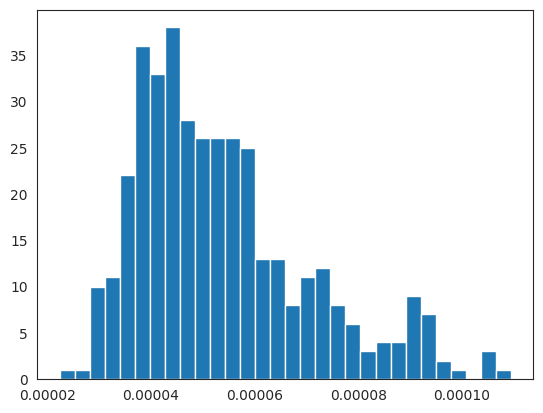

In [81]:
X10_hat = W10 @ H10
rmse = np.sqrt(np.mean((X - X10_hat)**2, axis=0)) 
plt.hist(rmse, bins=30)
plt.show()

In [87]:
names = allplayers.loc[pids, 'DISPLAY_FIRST_LAST'].to_numpy()
order = np.argsort(rmse)
best_idx = order[:10]
worst_idx = order[-10:][::-1]
print('Best fit:')
for j in best_idx:
    print(names[j], rmse[j])
print('\nWorst fit:')
for j in worst_idx:
    print(names[j], rmse[j])


Best fit:
Montrezl Harrell 2.2442358312563803e-05
DeAndre Jordan 2.6613317615674935e-05
Jarrett Allen 2.8390271269161957e-05
Rudy Gobert 2.8981161428830036e-05
Andre Drummond 2.912390241643423e-05
Ben Simmons 2.9628788713042327e-05
LeBron James 2.99692203136207e-05
Jusuf Nurkic 3.0376161205743004e-05
Kyle Kuzma 3.049496015355191e-05
D'Angelo Russell 3.057518280285802e-05

Worst fit:
Brad Wanamaker 0.00010946061707727061
Jaylen Adams 0.00010528051590008862
Jarell Martin 0.00010513866382879454
John Jenkins 0.00010455189126062514
Jose Calderon 0.00010061965211068647
Courtney Lee 9.67506095763623e-05
Channing Frye 9.661133113434831e-05
Danuel House Jr. 9.493766315901391e-05
Shaun Livingston 9.457634309994973e-05
Jordan McRae 9.433229813235466e-05


With 10 NMF components, the model captures the shots of most players pretty good but there are some players whose shots arent explained very well. We can see a right skew indicating that most players shooting was captured well, but there is a  number of players in the higher error. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

### Question 5d: Comparing Players

The coefficient matrix `H10` allows us to compare any pair of players based on how they combine the 10 basis shooting patterns.

For all player pairs $(i, j)$, compute the **Euclidean distance** between their coefficient vectors:
$$d_{ij} = \|H_{:,i} - H_{:,j}\|_2 = \sqrt{\sum_{k=1}^{10}(H_{k,i} - H_{k,j})^2}$$

This measures how similar two players' shooting styles are in the NMF representation.

</div>

**SOLUTION**

In [104]:
A = H10.T
row_norm2 = np.sum(A**2, axis=1, keepdims=True)
D2 = row_norm2 + row_norm2.T - 2 * (A @ A.T)
D2 = np.maximum(D2, 0)
D = np.sqrt(D2)
D.shape 

(388, 388)

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<div class="alert alert-block alert-success">

### Question 5e: Proposing improvements

One of the most common uses of unsupervised learning is to uncover unexpected structures in data. Given your analysis, what improvements could be made to either the data collection, analysis, or visualization to better understand players' shot preferences?

State any insights and defend your conclusions with visual and/or numerical comparisons.
</div>

**SOLUTION**

<!-- END QUESTION -->

_Cell Intentionally Blank_

I think that because NMF was able to capture shooting patterns / locations for players, such as midrange, wing, and corner, it was best used with players who had more predictable shooting location. It performed worse on players who did not follow a pattern and caught too much noise. An improvement could be to normalize the data better and look at residuals more closely. 


## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [ ]:
# Save your notebook first, then run this cell to export your submission.
grader.export(filtering=False, run_tests=True)